# Parte A - Auditoría técnica de scoring crediticio

Este notebook guía el análisis cuantitativo del sistema de aprobación de crédito. El modelo predice `default_real=1`; se aprueba el crédito si `prob_default < threshold`.

In [1]:
import pandas as pd
import numpy as np
import joblib
from sklearn.metrics import confusion_matrix, accuracy_score, precision_score, recall_score, f1_score
import matplotlib.pyplot as plt

DATA = "creditos_dataset.csv"
PREDS = "predicciones_creditos.csv"
MODEL = "modelo_creditos.pkl"

df = pd.read_csv(DATA)
pred = pd.read_csv(PREDS)
model_pack = joblib.load(MODEL)
model = model_pack["pipeline"]
threshold = model_pack["threshold_default"]
features = model_pack["features"]

df.head(), pred.head(), threshold

/home/carlos-acuna/Projects/fundaments-of-ai/fundaments-of-artificial-intelligence/.venv/lib/python3.12/site-packages/sklearn/base.py:525: InconsistentVersionWarning: Trying to unpickle estimator OneHotEncoder from version 1.8.0 when using version 1.9.0. This might lead to breaking code or invalid results. Use at your own risk. For more info please refer to:
https://scikit-learn.org/stable/model_persistence.html#security-maintainability-limitations
  warnings.warn(
/home/carlos-acuna/Projects/fundaments-of-ai/fundaments-of-artificial-intelligence/.venv/lib/python3.12/site-packages/sklearn/base.py:525: InconsistentVersionWarning: Trying to unpickle estimator FunctionTransformer from version 1.8.0 when using version 1.9.0. This might lead to breaking code or invalid results. Use at your own risk. For more info please refer to:
https://scikit-learn.org/stable/model_persistence.html#security-maintainability-limitations
  warnings.warn(
/home/carlos-acuna/Projects/fundaments-of-ai/fundament

(   id grupo  ingreso_mensual  antiguedad_laboral_anios  historial_crediticio  \
 0   1     A             7213                       3.6                   747   
 1   2     A             8264                       6.6                   593   
 2   3     B             5074                       3.8                   566   
 3   4     A             6112                       8.1                   567   
 4   5     A             5009                       1.7                   647   
 
    edad  codigo_postal_riesgo tipo_empleo  deuda_ingreso  default_real  \
 0    42                 0.521     estable          0.161             0   
 1    47                 0.338     estable          0.233             0   
 2    28                 0.753    autonomo          0.384             1   
 3    56                 0.272    autonomo          0.362             0   
 4    48                 0.165    autonomo          0.166             0   
 
     conjunto  
 0  auditoria  
 1  auditoria  
 2  auditori

## 1. Performance global
Calcular métricas globales para la predicción de default.

In [2]:
def metrics_table(data, group_col=None):
    groups = [("GLOBAL", data)] if group_col is None else [(g, d) for g,d in data.groupby(group_col)]
    rows = []
    for g, d in groups:
        y = d["default_real"]
        yhat = d["pred_default"]
        tn, fp, fn, tp = confusion_matrix(y, yhat, labels=[0,1]).ravel()
        rows.append({
            "grupo": g,
            "n": len(d),
            "approval_rate": d["aprobado_modelo"].mean(),
            "default_rate_real": y.mean(),
            "accuracy": accuracy_score(y, yhat),
            "precision_default": precision_score(y, yhat, zero_division=0),
            "recall_default_TPR": recall_score(y, yhat, zero_division=0),
            "f1_default": f1_score(y, yhat, zero_division=0),
            "FPR_default": fp/(fp+tn) if (fp+tn)>0 else np.nan,
            "FNR_default": fn/(fn+tp) if (fn+tp)>0 else np.nan,
            "TN": tn, "FP": fp, "FN": fn, "TP": tp
        })
    return pd.DataFrame(rows)

global_metrics = metrics_table(pred)
global_metrics

,grupo,n,approval_rate,default_rate_real,accuracy,precision_default,recall_default_TPR,f1_default,FPR_default,FNR_default,TN,FP,FN,TP
0,GLOBAL,490,0.773469,0.087755,0.742857,0.126126,0.325581,0.181818,0.217002,0.674419,350,97,29,14


## 2. Fairness por grupo
Grupo A es referencia; Grupo B es el grupo protegido para esta auditoría.

In [3]:
by_group = metrics_table(pred, "grupo")
by_group

,grupo,n,approval_rate,default_rate_real,accuracy,precision_default,recall_default_TPR,f1_default,FPR_default,FNR_default,TN,FP,FN,TP
0,A,282,0.914894,0.056738,0.879433,0.125000,0.187500,0.150000,0.078947,0.812500,245,21,13,3
1,B,208,0.581731,0.129808,0.557692,0.126437,0.407407,0.192982,0.419890,0.592593,105,76,16,11


In [4]:
appr = by_group.set_index("grupo")["approval_rate"]
ratio_80 = appr["B"] / appr["A"]
gap_abs = abs(appr["A"] - appr["B"])

fpr = by_group.set_index("grupo")["FPR_default"]
fnr = by_group.set_index("grupo")["FNR_default"]
delta_fpr = abs(fpr["A"] - fpr["B"])
delta_fnr = abs(fnr["A"] - fnr["B"])

summary = pd.DataFrame([
    {"indicador":"Regla del 80%", "valor":ratio_80, "umbral":"< 0.80", "falla": ratio_80 < 0.80},
    {"indicador":"Gap absoluto aprobación", "valor":gap_abs, "umbral":"> 0.10", "falla": gap_abs > 0.10},
    {"indicador":"Delta FPR", "valor":delta_fpr, "umbral":"> 0.05", "falla": delta_fpr > 0.05},
    {"indicador":"Delta FNR", "valor":delta_fnr, "umbral":"> 0.05", "falla": delta_fnr > 0.05},
])
summary

,indicador,valor,umbral,falla
0,Regla del 80%,0.635845,< 0.80,True
1,Gap absoluto aprobación,0.333163,> 0.10,True
2,Delta FPR,0.340942,> 0.05,True
3,Delta FNR,0.219907,> 0.05,True


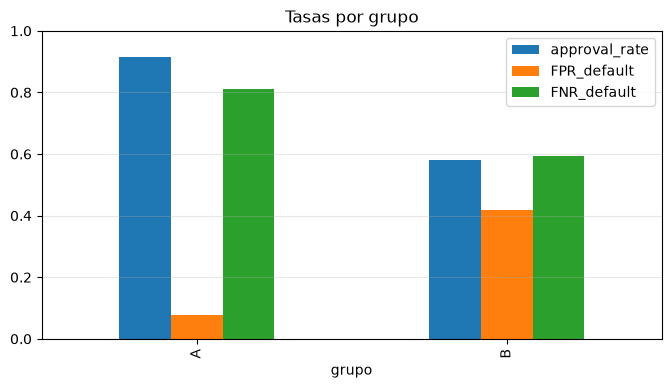

In [5]:
ax = by_group.set_index("grupo")[["approval_rate","FPR_default","FNR_default"]].plot(kind="bar", figsize=(8,4))
plt.title("Tasas por grupo")
plt.ylim(0,1)
plt.grid(axis="y", alpha=0.3)
plt.show()

## 3. Caso individual para LIME y SHAP
Seleccionamos un caso rechazado del Grupo B. Pueden cambiar `case_id` para analizar otro caso.

In [6]:
# Caso fijo para que LIME/SHAP y las explicaciones precalculadas correspondan al mismo registro
case_id = 775
case = pred[pred.id == case_id].iloc[0]
case[features + ["grupo", "prob_default", "pred_default", "aprobado_modelo", "default_real"]]


ingreso_mensual                 7467
antiguedad_laboral_anios         2.4
historial_crediticio             453
edad                              32
codigo_postal_riesgo           0.575
tipo_empleo                 autonomo
deuda_ingreso                  0.535
grupo                              B
prob_default                 0.48765
pred_default                       1
aprobado_modelo                    0
default_real                       0
Name: 412, dtype: object

## 4. LIME simplificado
Si no está instalada la librería `lime`, usamos una implementación didáctica: perturbamos localmente la instancia, consultamos al modelo opaco y ajustamos una regresión ponderada por cercanía.

In [7]:
from sklearn.linear_model import Ridge
from sklearn.preprocessing import StandardScaler

def lime_simplificado(case_id, n_samples=600, seed=42):
    rng = np.random.default_rng(seed)
    row = pred[pred.id == case_id].iloc[0]
    x0 = row[features].to_frame().T
    train = df[df.conjunto == "train"][features].copy()
    num_feats = [f for f in features if f != "tipo_empleo"]
    pert = []
    for _ in range(n_samples):
        d = {}
        for f in num_feats:
            sd = train[f].std() * 0.12
            d[f] = float(np.clip(rng.normal(float(x0[f].iloc[0]), sd), train[f].min(), train[f].max()))
        d["tipo_empleo"] = x0["tipo_empleo"].iloc[0] if rng.random() < 0.8 else rng.choice(train["tipo_empleo"].values)
        pert.append(d)
    pert = pd.DataFrame(pert)[features]
    y_local = model.predict_proba(pert)[:,1]
    scaler = StandardScaler().fit(train[num_feats])
    z = scaler.transform(pert[num_feats])
    z0 = scaler.transform(x0[num_feats])
    dist = np.sqrt(((z - z0)**2).sum(axis=1)) + (pert["tipo_empleo"].values != x0["tipo_empleo"].iloc[0]).astype(float)*0.4
    weights = np.exp(-(dist**2)/(1.0**2))
    Xloc = pd.get_dummies(pert, columns=["tipo_empleo"], drop_first=False)
    X0 = pd.get_dummies(x0, columns=["tipo_empleo"], drop_first=False)
    for c in Xloc.columns:
        if c not in X0: X0[c] = 0
    X0 = X0[Xloc.columns]
    mu = Xloc.mean(); sd = Xloc.std().replace(0,1)
    Xs = (Xloc - mu) / sd
    X0s = (X0 - mu) / sd
    surrogate = Ridge(alpha=1.0).fit(Xs, y_local, sample_weight=weights)
    contrib = surrogate.coef_ * X0s.iloc[0].values
    out = pd.DataFrame({"feature": Xloc.columns, "contribution_to_prob_default": contrib})
    return out.reindex(out.contribution_to_prob_default.abs().sort_values(ascending=False).index).head(10)

lime_simplificado(case_id)

,feature,contribution_to_prob_default
7,tipo_empleo_estable,0.007072
6,tipo_empleo_autonomo,0.005359
8,tipo_empleo_temporal,-0.001837
5,deuda_ingreso,-0.000224
3,edad,-0.000137
4,codigo_postal_riesgo,-0.000099
0,ingreso_mensual,-0.000014
1,antiguedad_laboral_anios,0.000012
2,historial_crediticio,-0.000007


## 5. SHAP
Si `shap` está instalado, se calcula sobre el Random Forest. Si no, usar el archivo `explicaciones_precalculadas_lime_shap.csv`.

In [8]:
try:
    import shap
    x_case = pred[pred.id == case_id][features]
    Xt = model.named_steps["pre"].transform(x_case)
    feature_names = list(model.named_steps["pre"].get_feature_names_out())
    explainer = shap.TreeExplainer(model.named_steps["rf"])
    sv = explainer.shap_values(Xt)
    if isinstance(sv, list):
        vals = sv[1][0]
        base = explainer.expected_value[1]
    else:
        arr = np.array(sv)
        if arr.ndim == 3:
            vals = arr[0,:,1]
            base = np.array(explainer.expected_value)[1]
        else:
            vals = arr[0]
            base = np.array(explainer.expected_value).ravel()[0]
    shap_df = pd.DataFrame({"feature":feature_names, "shap_value_default":vals})
    display(shap_df.reindex(shap_df.shap_value_default.abs().sort_values(ascending=False).index).head(10))
    print("Valor base aproximado:", base)
    print("Probabilidad de default del caso:", float(pred[pred.id==case_id]["prob_default"].iloc[0]))
except Exception as e:
    print("No se pudo calcular SHAP en este entorno:", e)
    display(pd.read_csv("explicaciones_precalculadas_lime_shap.csv"))

/home/carlos-acuna/Projects/fundaments-of-ai/fundaments-of-artificial-intelligence/.venv/lib/python3.12/site-packages/tqdm/auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm


,feature,shap_value_default
3,num__ingreso_mensual,-0.106354
6,num__edad,-0.042678
5,num__historial_crediticio,0.035561
8,num__deuda_ingreso,0.031727
7,num__codigo_postal_riesgo,0.027910
1,cat__tipo_empleo_estable,0.026169
4,num__antiguedad_laboral_anios,0.016255
0,cat__tipo_empleo_autonomo,0.007811
2,cat__tipo_empleo_temporal,-0.004621


Valor base aproximado: 0.4958699421386073
Probabilidad de default del caso: 0.48765


## 6. Mitigación
Ejemplo: umbral diferenciado o revisión humana para zona gris. Ustedes deben proponer al menos dos estrategias y cuantificar trade-offs.

In [9]:
def evaluate_thresholds(th_A=0.40, th_B=0.40):
    d = pred.copy()
    d["threshold"] = np.where(d.grupo == "A", th_A, th_B)
    d["pred_default_mitigado"] = (d.prob_default >= d.threshold).astype(int)
    d["aprobado_mitigado"] = (d.prob_default < d.threshold).astype(int)
    old_cols = d[["id","grupo","default_real","pred_default","aprobado_modelo"]].copy()
    d2 = d.rename(columns={"pred_default":"pred_default_original", "aprobado_modelo":"aprobado_original", "pred_default_mitigado":"pred_default", "aprobado_mitigado":"aprobado_modelo"})
    return metrics_table(d2, "grupo")

# Ejemplo: aumentar levemente el umbral de aprobación para Grupo B reduce disparidad de aprobación, pero puede cambiar errores.
evaluate_thresholds(th_A=0.40, th_B=0.46)

,grupo,n,approval_rate,default_rate_real,accuracy,precision_default,recall_default_TPR,f1_default,FPR_default,FNR_default,TN,FP,FN,TP
0,A,282,0.914894,0.056738,0.879433,0.125000,0.187500,0.150000,0.078947,0.812500,245,21,13,3
1,B,208,0.716346,0.129808,0.663462,0.135593,0.296296,0.186047,0.281768,0.703704,130,51,19,8


## 7. Preguntas para completar el informe
1. ¿Qué métrica global podría ocultar un problema por grupo?
2. ¿Qué indicador falla con mayor claridad?
3. ¿Qué variables parecen proxies?
4. ¿LIME y SHAP explican o justifican?
5. ¿Qué mitigación recomendarían y qué costo tiene?
6. Decisión: desplegar, condicionar o detener.